In [14]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
import seaborn as sns
import matplotlib.pyplot as plt


In [15]:

# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv("/kaggle/input/datasets/luckysingh7220/tweetsl/Tweets (1).csv")

# Clean column names
df.columns = df.columns.str.strip()

print("Columns:", df.columns)
print(df.head())

Columns: Index(['textID', 'text', 'selected_text', 'sentiment'], dtype='object')
       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  


In [16]:
# ================================
# 3. PREPROCESS DATA
# ================================
TEXT_COL = "text"
LABEL_COL = "sentiment"

# Drop missing values
df = df[[TEXT_COL, LABEL_COL]].dropna()

texts = df[TEXT_COL].astype(str).tolist()

# 3-class mapping
label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

labels = [label_map[x] for x in df[LABEL_COL]]

# OPTIONAL: reduce size if training is slow
# df = df.sample(2000)

In [17]:
# ================================
# 4. TOKENIZATION
# ================================
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

encodings = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

In [18]:

# ================================
# 5. DATASET CLASS
# ================================
class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

dataset = TweetDataset(encodings, labels)


In [19]:
# ================================
# 6. DATALOADER
# ================================
loader = DataLoader(dataset, batch_size=8, shuffle=True)

# ================================
# 7. LOAD MODEL (3 classes)
# ================================
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3,
    output_attentions=True
)

optimizer = AdamW(model.parameters(), lr=2e-5)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [20]:
# ================================
# 8. TRAINING LOOP
# ================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(5):
    model.train()
    total_loss = 0

    for i, batch in enumerate(loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Final Loss: {total_loss/len(loader):.4f}")


Epoch 1 Final Loss: 0.5723
Epoch 2 Final Loss: 0.3996
Epoch 3 Final Loss: 0.2556
Epoch 4 Final Loss: 0.1496
Epoch 5 Final Loss: 0.1009


In [21]:
# ================================
# 9. ATTENTION VISUALIZATION
# ================================
def visualize_attention(text):
    model.eval()

    inputs = tokenizer(text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    attentions = outputs.attentions

    # Last layer, first head
    attention = attentions[-1][0][0].cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    plt.figure(figsize=(10,8))
    sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
    plt.title("Attention Heatmap")
    plt.xticks(rotation=90)
    plt.show()


In [22]:
# ================================
# 10. PREDICTION FUNCTION
# ================================
label_names = {0: "negative", 1: "neutral", 2: "positive"}

def predict(text):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    pred = torch.argmax(logits, dim=1).item()

    print("Text:", text)
    print("Predicted Sentiment:", label_names[pred])


Text: I love this phone but the battery is average
Predicted Sentiment: positive


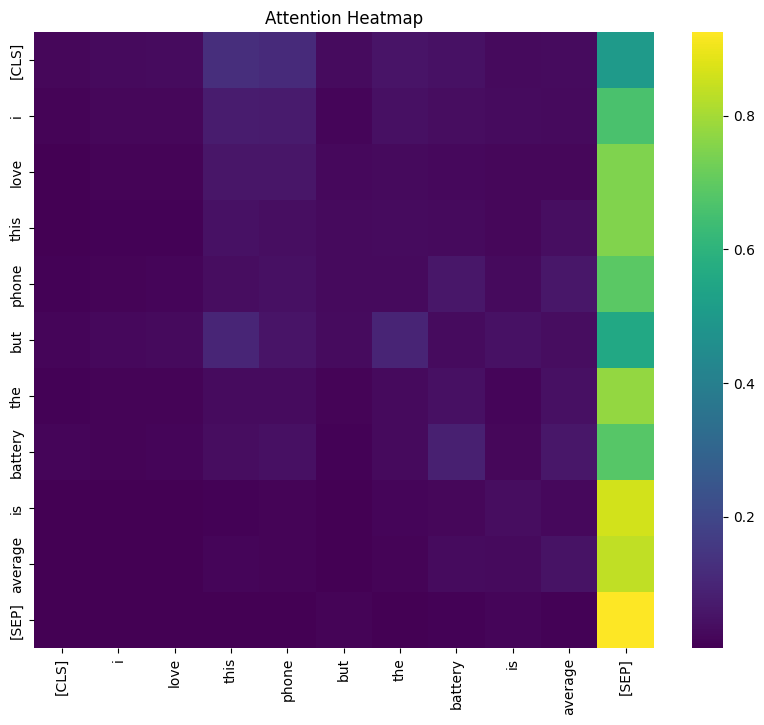

In [23]:

# ================================
# 11. TEST
# ================================
test_tweet = "I love this phone but the battery is average"

predict(test_tweet)
visualize_attention(test_tweet)